# Dimension Reduction

## Stochastic Neighbor Embedding (SNE)

The objective of this method is to find an appropriate representation of a set of $n$ data points in dimension $d$ of space $(x_1, x_2, \cdots, x_n) \in \mathbb{R}^{n \times d}$ into a space of dimension $d' \leq d$. This resulting data set is noted $(y_1, y_2, \cdots, y_n) \in \mathbb{R}^{n \times d'}$.

The key idea of t-SNE is to conserve distance between points, independantly of their precise configuration. First, define the conditional probability that particle $j$ is at a given distance of particle $i$:
$$
p_{j|i} = \frac{e^{-||x_i - x_j||^2/(2\sigma_i^2)}}{\sum\limits_{k \neq i}e^{-||x_i - x_k||^2/(2\sigma_i^2)}},
$$
meaning that each particle is the center of a gaussian law of variance $\sigma^2_i$ describing the probability density of its neighbouring points.
Very similarly, now define:
$$
q_{j|i} = \frac{e^{-||y_i - y_j||^2}}{\sum\limits_{k \neq i}e^{-||y_i - y_k||^2}}.
$$

Note that the distance appearing in $p_{j|i}$ are in $\mathbb{R}^d$ whereas the distance is in $\mathbb{R}^{d'}$ for $q_{i|j}$.
We set $\forall i \in \{1, \cdots, d' \}, q_{i|i}=p_{i|i}=0$.

The goal is then to find the points $(y_1, y_2, \cdots, y_n) \in \mathbb{R}^{n \times d'}$ that minimizes the discrepency between $q_{i|j}$ and $p_{i|j}$. We take here a strong metric, namely, the Kullback-Leibler divergence:
$$
C = KL(P||Q) = \sum\limits_{i=1}^n KL(P_i||Q_i) = \sum\limits_{i=1}^n \sum_{j = 1}^n p_{j|i} \log(\frac{p_{j|i}}{q_{j|i}}) = \sum\limits_{i=1}^n H(P_i||Q_i) - H(P_i),
$$
assuming $\frac{p_{i|i}}{q_{i|i}} = 1$. Note that $Q$ is the distribution on the right side of the divergence, meaning that it is equivalent to a Maximum likelihood objective. The optimal point will be find via a first order steepest ascent method. Keeping only terms with $Q_i$ in the KL divergence, one obtains:
$$
KL(P_i, Q_i) \propto -\sum_{j=1}^n p_{j|i}\log(q_{j|i}) = \sum_{j=1}^n p_{j|i} \bigg(||y_i - y_j||^2 + \log\big(\sum\limits_{k\neq i} e^{-||y_k - y_i||^2}\big) \bigg)
$$

A major weakness appears here, the objective function is not convex w.r.t $(y_1, \cdots, y_n)$.

The main remaining question is: how to choose the 'best' $\sigma_i$ for each particle $i$. A small $\sigma_i$ is suited for dense regions, while large $\sigma_i$ is very much relevant for sparse regions.

With this objective in mind, one can define the perplexity of $p_i = p_{\cdot|j}$ as $\text{Perp}(p_i) = 2^{H(p_i)}$, where the entropy $H$ of $p_i$ is $H(p_i) = -\sum\limits_{j=1}^n p_{j|i} \log(p_{j|i})$. Small perplexity put emphasis on local structure, because it requires a small $\sigma_i$. On the opposite, a large perplexity put more emphasis on the global structure.
The operator fixes a perplexity target $P_i$, one per particle $X_i$ in the data set, and SNE performs a binary search (by taking the geometric mean) for the value of $\sigma_i$ that produce this value. It can be done with a binary search precisely because the entropy is an increasing function of $\sigma_i$, one can convince ourself easily with a little bit of physical intuition by interpreting $\sigma_i$ as a temperature. Typical value of particle perplexity should be between $5$ and $50$. Perplexity is a smooth effective measure of the number of neighbours.

To perform gradient ascent, the gradient of the Kullback-Leibler divergence w.r.t $Y_i$ should be computed. It admits a surprising simple expression:
$$
\frac{\partial C}{\partial y_i} = 2\sum\limits_{j=1}^n (p_{j|i} - q_{j|i} + p_{i|j} - q_{i|j})(y_i - y_j)
$$

An updates takes the form, $\forall i \in \{1, \cdots, d'\}$:
$$
\begin{equation}
y_{i}^{(n+1)} =y_i^{(n)} + \eta_n \frac{\partial C}{\partial y_i} + \alpha_n(y_i^{(n)} - y_i^{(n-1)}),
\end{equation}
$$
where $\eta_n$ is the learning rate and $\alpha_n$ is the momentum parameter at iteration $n$.

During the first iterations, a gaussian noise with decreasing variance is added.

In a nutshell, I should make a method to compute $p_{i|j}$, which amounts to compute the distance $||x_i - x_j||_2^2$ for all pairs of points. I should make another method to figure out an appropriate $\sigma_i$ for each of the points. Eventually, a method to run the optimization algorithm is necessary.

[1] https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# def compute_kern_dist(X: np.ndarray, kern: callable):
#     return kern(X, X)

def compute_sq_eucl_dist(X: np.ndarray):
    """
    Compute the squared euclidian distance between all pairs of points.
    """
    return np.sum(X**2, axis=-1)

def compute_pji(X: np.ndarray, sigma: np.ndarray):
    """
    Compute the distribution matrix whose i-th row and j-th column is the probability of having particle j at this distance from particle i.
    Args:
        - X (np.ndarray): Set of data point. It should be of shape (n x d), where n is the number of samples, and d the dimension of space they live in.
        - sigma (np.ndarray): Variange of the gaussian. It should be of shape (n,).
    """
    assert np.all(sigma > 0), "All entry in sigma array should be positive."
    dist = compute_sq_eucl_dist(X[None,...] - X[:,None,...]) #Compute the distance between all pairs of points.
    P = np.exp(-dist/sigma[:, None])
    np.fill_diagonal(P, 0)
    P /= (np.sum(P, axis=-1))[:,None]
    return P

def compute_qji(Y: np.ndarray):
    return compute_pji(Y, sigma=np.ones(len(Y)))

def compute_entropy(P: np.ndarray):
    assert np.abs(np.sum(P) - 1) < 1e-5, f"P should be a list of probabilities, but it sums to {np.sum(P)}."
    P = P[P>0]
    return -np.sum(P*np.log(P), axis = -1)

def sample_init(n: int, d: int, std: float=1e-2):
    """
    Initialize a set of points (y_1, ..., y_n) in the low dimensional space. It is done by sampling from a random variable.
    Args:
        std: standard deviation for the sampling.
        n: number of samples.
        d: dimension space.
    Returns:
        An array of shape (n, d).
    """
    assert std > 0, "The standard deviation should be positive."

    return np.random.randn(n, d)*std

def compute_grad_C(y: np.ndarray, matrix_pji: np.ndarray[np.ndarray], matrix_qji: np.ndarray[np.ndarray]):
    grad_C = np.empty((len(y), 2))
    
    for i in range(len(y)):
        vect_Y = y[i] - y
        p = matrix_pji[i] - matrix_qji[i]
        p += matrix_pji[:,i] - matrix_qji[:,i]
        grad_C[i] = 2*np.sum(p*vect_Y, axis=0)
    return grad_C

def find_sigma(X: np.ndarray, Perp_tar: np.ndarray):
    """Find the variance for a given perplexity target

    Args:
        X (np.ndarray): Dataset. Should be of shape (n x d). n is the number of samples and d the dimension of space.
        Perp (np.ndarray): Target perplexity for each points in the dataset.
    """
    assert len(X) == len(Perp_tar), "X and Perp_tar should be the same length"
    Sigma_BS = []

    for i, (x, perp) in enumerate(zip(X, Perp_tar)):
        entropy = np.infty
        sigma_min = 1e-2
        sigma_max = 1e5
        sigma = np.sqrt(sigma_max*sigma_min)
        dist = compute_sq_eucl_dist(x - X) #Compute the distance between all pairs of points.
        vect = np.exp(-dist/sigma)
        vect[i] = 0
        vect /= np.sum(vect)
        entropy = compute_entropy(vect)
        while np.abs(np.power(2, entropy) - perp) > 1e-5:
            vect = np.exp(-dist/sigma)
            vect[i] = 0
            vect /= np.sum(vect)
            entropy = compute_entropy(vect)
            if np.power(2, entropy) > perp:
                sigma_max = sigma
                sigma = np.sqrt(sigma*sigma_min)
            else:
                sigma_min = sigma
                sigma = np.sqrt(sigma*sigma_max)
        Sigma_BS.append(sigma)
    return Sigma_BS

if __name__ == "__main__":
    A = np.array([[2, 1], [0, 0], [10, -5]])
    sigma = np.array([1, 10, 2])
    P = compute_pji(A, sigma)
    Q = compute_qji(sample_init(3, 2))
    Sigma = find_sigma(A, np.ones(3))
    print(Sigma)

[4.216965034285822, 4.216965034285822, 4.216965034285822]


## t-distributed Stochastinc Neighbor Embedding (t-SNE)

While it is very similary to SNE, it possess two major differences. The first one is the use of symmetrized cost with simpler gradients, and the second one is that probability density are represented by a t-distribution, and not a Gaussian distribution anymore. Symmetrized probability distribution are more robust to outlier

One introduces the symmetrized probability:
$$
p_{ij} = \frac{p_{i|j} + p_{j|i}}{2n}.
$$

One then introduces the symmetrized cost:
$$
KL(P||Q) = \sum\limits_{i=1}^n \sum\limits_{j=1}^n p_{ij} \log(\frac{p_{ij}}{q_{ij}}),
$$
with as before $\forall i \in \{1, \cdots, d'\}, \, p_{ii} = q_{ii} = 0$.

The second changement is the ansatz on $q_{ij}$. The unkowns are still the positions $(y_1, \cdots, y_n) \in \mathbb{R}^{n\times d'}$, but this time, the density family is the Student distribution $\forall i\neq j$:
$$
q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum\limits_{k=1}^n \sum\limits_{l \neq k} (1 + ||y_l - y_k||^2)^{-1}},
$$
so that the renormalization constant implies $\sum\limits_{i, j} q_{ij} = 1$.

The gradient simply becomes:
$$
\frac{\partial C}{\partial y_i} = 4 \sum_{j=1}^n(p_{ij} - q_{ij})(y_i - y_j)(1 + ||y_i - y_j||^2)^{-1},
$$
and the optimization scheme is the same as (1).

The optimization of the t-SNE objective function is much easier than the cost function of SNE. A fixed number of $T = 1000$ timestep is fixed. The momentum term should be $\alpha(t) = .5$ if $t < 250$ and $\alpha(t) = .8$ if $t \geq 250$.


In [ ]:
def compute_symm_pij(X: np.ndarray, sigma):
    """
    Compute the symmetric probability distribution.
    """
    matrix = compute_pji(X, sigma)
    matrix += matrix.T
    matrix /= 1/(2*len(X))
    return matrix

def compute_symm_qij(Y: np.ndarray):
    """
    Compute student's distribution.
    """
    Q = 1/(1 + compute_sq_eucl_dist(Y[None,...] - Y[:,None,...]))
    np.fill_diagonal(Q, 0) #Cancel the diagonal terms
    Q /= np.sum(Q)
    return Q

def compute_grad_C(y: np.ndarray, matrix_pij: np.ndarray[np.ndarray], matrix_qij: np.ndarray[np.ndarray]):
    """
    Compute the gradient of the KL divergence w.r.t matrix_pij and matrix_qij.
    Args:
        y (np.ndarray): data at which compute we compute the gradient.
        matrix_pij (np.ndarray): symmetrized probability matrix for p.
        matrix_qij (np.ndarray): symmetrized probability matrix for q.
    Returns:
        A array of shape (n,2).
    """
    grad_C = np.empty((len(y), 2))
    for i in range(len(y)):
        p = matrix_pij[i]
        q = matrix_qij[i]
        dist = 1/(1 + np.sum((y[i] - y)**2, axis = -1)) #Sum along coordinates axis
        grad_C[i] = 4*np.sum((p-q)*(y[i] - y)*dist, axis=0) #Sum along batch axis
    return grad_C

## Non-Negative Matrix Factorization (NMF)

Matrix factorization refers to a set of computational technique to write any matrix $A \in \mathbb{R}^{n \times p}$ as a product of two or more structured matrices. A first advantage is that one can often take advantage of their structure to store them in a most efficient way than simply naively storing all elements of $A$. Indeed, in general, the space complexity of storing a standard matrix scales as $\mathcal{O}(np)$. However, if $A$ writes as $A=HW$, with $H \in \mathbb{R}^{n\times k}$ and $W \in \mathbb{R}^{k \times p}$ and $k$ a **choosen parameter**, then the storage space complexity scales as $\mathcal{O}((n+p)k)$. If $k \ll \min(p, n)$, then the storage of the two matrices $H$ and $W$ instead of the single $A$ becomes much more economical. Another reason is the dimension reduction, since one compresses in some sense the size of the feature space from $p$ elements to only $k$.

In Non-Negative Matrix Factorization, the objective is to find two such matrices $H$ and $W$ with the constraints that all their entries are positive, assuming that all entries of $A$ are positive. If $n$ is the number of samples, and $p$ the number of features, then $H$ is called the basis matrix and $W$ the components matrix.
Noting $||\cdot||$ the Frobenius norm, $H$ and $W$ should be the solutions to this optimization problem:
$$
\begin{array}{cc}
\min\limits_{H \in \mathbb{R}^{n \times k}, W \in \mathbb{R}^{k \times p}} & \frac12||A - HW||^2 \\
\text{s.t} & H\geq 0, W \geq 0
\end{array}
$$

Without further assumptions, the problem above is not convex because its objective function is not convex, making $\textit{de-facto}$ its resolution complex, several solutions may exist. If one imposes an additional constraint: $H H^\top = \text{Id}$, then it is mathematically equivalent to K-means clustering [1], which is known to be NP-Hard.

Of course, many variants exists, including $L^1$ and $L^2$ regularization. The more general regularized optimization problem being:
$$
\begin{array}{cc}
\min\limits_{H \in \mathbb{R}^{n \times k}, W \in \mathbb{R}^{k \times p}} & \frac12||A - HW||^2 + \alpha_1 p ||H||_1 + \beta_1 n ||W||_1 + \frac12\alpha_2 p ||H||^2 + \frac12\beta_2 n ||W||^2,\\
\text{s.t} & H\geq 0, W \geq 0,
\end{array}
$$
with, of course, $||W||_1 = \sum\limits_{i,j} |W_{i,j}|$.
In practice, the first optimization problem is solved via a multiplicative update rule, as published in [2]. It consists in iterating successively:
$$
\begin{array}{cc}
H \leftarrow \frac{H \odot (W^\top V)}{W^\top W H}, & W \leftarrow \frac{W \odot (VH^\top)}{WHH^\top},
\end{array}
$$
where $\odot$ denotes the Hadamard product and the division is entry-wise.

Another possibility is to minimize the KL divergence between $A$ and $WH$. The formulation is:
$$
\begin{array}{cc}
\min\limits_{H \in \mathbb{R}^{n \times k}, W \in \mathbb{R}^{k \times p}} & D_{KL}(A||WH) \\
\text{s.t} & H\geq 0, W \geq 0
\end{array}
$$
The multiplicative update rule takes the form:
$$
\begin{array}{cc}
H_{a, \mu} \leftarrow H_{a,\mu} \displaystyle\frac{\sum\limits_{i=1}^n W_{i,a} A_{i,\mu}/(WH)_{i,\mu}}{\sum\limits_{k=1}^n W_{ka}} , & W_{i,a} \leftarrow W_{i,a}\displaystyle\frac{\sum\limits_{\mu=1}^p H_{a, \mu} A_{i,\mu}/(WH)_{i,\mu}}{\sum\limits_{\nu = 1}^p H_{a, \nu}},
\end{array}
$$
or otherwise written:
$$
H \leftarrow H \odot \frac{W^\top (A/WH)}{\mathbb{1}^\top W}, W \leftarrow W \odot \frac{H (A/WH)^\top}{H \mathbb{1}},
$$
where $\mathbb{1}$ is a vector filled with ones.

The KL divergence admits the following expression for vectors whose entries do not sum up to $1$: $D_{KL}(U||V) = \sum\limits_{i=1}^n \log(\frac{u_i}{v_i})u_i + v_i - u_i$

[1]. https://ranger.uta.edu/~chqding/papers/NMF-SDM2005.pdf

[2]. https://proceedings.neurips.cc/paper_files/paper/2000/file/f9d1152547c0bde01830b7e8bd60024c-Paper.pdf

In [ ]:
import numpy as np
def NMF_norm(X: np.ndarray, n_components: int=2, max_iter: int=300, tol: float=1e-4):
    """
    Compute a Non-Negative Matrix Factorization of X. No regularization is added to the objective function.
    Args:
        X (np.ndarray). Non-Negative Data set. Each row is a data, and each column represents a feature.
        n_components (int). Number of components in the factorized matrices.
        max_iter (int). Maximum number of iterations.
        tol (float). Criteria to if the reconstruction is a good approximation of X.
    Returns:
        Two Non-negative numpy arrays H and W.
    """

    if not isinstance(X, np.ndarray):
        X = np.array(X)
    assert np.all(X >= 0), 'All entries of X should be non-negative'

    n_sample, n_feature = X.shape

    W = np.random.rand(n_sample, n_components)
    H = np.random.rand(n_components, n_feature)
    
    counter=0
    while counter <= max_iter or np.linalg.norm(X - W@H)>tol:
        counter += 1
        
        #1st rule
        WH = W.T @ W @ H
        H *= W.T @ X / (WH)
 
        #2nd rule
        WHT = W @ H @ H.T
        W *= (X@H.T)/WHT
    return W, H

def NMF_KL(X: np.ndarray, n_components: int=2, max_iter: int=50, tol: float=1e-4):
    """
    Compute a Non-Negative Matrix Factorization of X. No regularization is added to the objective function. The approximation is on the sense of the
    KL divergence.
    Args:
        X (np.ndarray). Non-Negative Data set. Each row is a data, and each column represents a feature.
        n_components (int). Number of components in the factorized matrices.
        max_iter (int). Maximum number of iterations.
        tol (float). Criteria to if the reconstruction is a good approximation of X.
    Returns:
        Two Non-negative numpy arrays H and W.
    """

    if not isinstance(X, np.ndarray):
        X = np.array(X)
    assert np.all(X >= 0), 'All entries of X should be non-negative'
    n_sample, n_feature = X.shape
    
    W = np.random.rand(n_sample, n_components)
    H = np.random.rand(n_components, n_feature)

    counter=0
    while counter <= max_iter or np.sum(np.log(X/(W@H))*X - X + W@H)>tol:
        counter += 1

        #1st rule
        X_norm = X/(W@H)
        H *= W.T @ X_norm / np.sum(W, axis=0)

        #2nd rule
        X_norm = X/(W@H)
        W *= X_norm @ H.T / np.sum(H, axis=1)
    return W, H

if __name__=='__main__':
    import numpy as np
    X = np.array([[1, 1], [2, 1], [3, 1.2], [4, 1], [5, 0.8], [6, 1]])
    from sklearn.decomposition import NMF
    model = NMF(n_components=2, init='random', random_state=0)
    W = model.fit_transform(X)
    H = model.components_
    print(np.linalg.norm(X - W@H))
    W, H = NMF_norm(X, n_components=2, max_iter=300)
    print(np.linalg.norm(X - W@H))
    W, H = NMF_KL(X, n_components=2, max_iter=256)
    print(np.sum(np.log(X/(W@H))*X - X + W@H))

0.0011599349216014024
9.967863800761315e-05
1.0834440443696636e-06


## Kernel Canonical Correlation Analysis

### Linear CCA
Take two multivariates random variables $X \in \mathbb{R}^n$ and $Y \in \mathbb{R}^m$. The objective of Canonical Correlation Analysis is to find the directions in $\mathbb{R}^n$ and $\mathbb{R}^m$ onto which $X$ and $Y$ are respectively projected while keeping as much variance as possible. Mathematically, it formulates as:
$$
\max\limits_{\substack{w_X \in \mathbb{R}^n, w_Y \in \mathbb{R}^m \\ w_X, w_Y \neq 0}} \frac{\text{Cov}(w_X^\top X, w_Y^\top Y)}{\sqrt{\mathbb{V}[w_X ^\top X]\mathbb{V}[w_Y^\top Y]}}
$$
For two real-valued univariate random variables U and V, the covariance operator is classically: $\text{Cov}(U, V) = \mathbb{E}[UV] - \mathbb{E}[U] \mathbb{E}[V]$.
Of course, it is not practicable to maximize such a quantity, because not only do we not know the probability measures $\mathbb{P}_X$, $\mathbb{P}_Y$ and $\mathbb{P}_{X,Y}$, but it would amount to maximise a parametric integral, which is far from trivial. Consequently, one solves its empirical counterpart. Take $(X, Y) = (x_i, y_i)_{i \in \{1, \cdots, N\}} \sim \mathbb{P}_{X, Y}^{\otimes N}$ and let:
$$
\max\limits_{\substack{w_X \in \mathbb{R}^n, w_Y \in \mathbb{R}^m \\ w_X, w_Y \neq 0}} \frac{\widehat{\text{Cov}}^N(w_X^\top X, w_Y^\top Y)}{\sqrt{\hat{\mathbb{V}}^N[w_X^\top X] \hat{\mathbb{V}}^N[w_Y^\top Y]}},
$$
where one defines $\widehat{\text{Cov}}^N(U, V) = \frac 1N\sum\limits_{i=1}^NU_iV_i - \frac 1{N^2} \sum\limits_{i=1}^NU_i \sum\limits_{i=1}^NV_i$ with $(U_i, V_i)_{i \in \{1, \dots, N\}} \sim \mathbb{P}_{(U, V)}^{\otimes N}$ $\text{i.i.d}$ samples from the joint law of monovariate random variables $U$ and $V$, and $\hat{\mathbb{V}}^N[U] = \frac 1n \sum\limits_{i=1}^N U_i^2 - \frac{1}{N^2} (\sum\limits_{i=1}^N U_i)^2$.

As it often happens in Machine Learning when dealing with linear methods, after a few manipulations, the problem reduces to an eigenvalue problem, here generalized. This simple observation directly implies that the temporal complexity scales as $\mathcal{O}(N^3)$, which is quite bad. Writing $\Sigma_{X, Y} = \mathbb{E}_{X, Y}[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])^\top]=\mathbb{E}_{X, Y}[X Y^\top] - \mathbb{E}_X[X]\mathbb{E}_Y[Y]^\top$, $\Sigma_X = \mathbb{E}_{X}[XX^\top] - \mathbb{E}_{X}[X]\mathbb{E}_{X}[X]^\top$, $\Sigma_Y = \mathbb{E}_{Y}[YY^\top] - \mathbb{E}_{Y}[Y]\mathbb{E}_{Y}[Y]^\top $ the covariance and variance matrices, and their (biased) respective estimators: $\hat{\Sigma}_{X, Y}^{(N)} = \frac 1N \sum\limits_{i=1}^{N}X_iY_i^\top - \frac 1{N^2} (\sum\limits_{i=1}^{N}X_i) (\sum\limits_{i=1}^{N}Y_i)^\top \in \mathbb{R}^{n \times m}$, $\hat{\Sigma}_X^{(N)} \equiv \hat{\Sigma}_{X, X}^{(N)} \in \mathbb{R}^{n \times n}, \hat{\Sigma}_Y^{(N)} \equiv \hat{\Sigma}_{Y, Y}^{(N)} \in \mathbb{R}^{m \times m}$. With this quantities, the original problem re-writes:
$$
\max\limits_{\substack{w_X \in \mathbb{R}^n, w_Y \in \mathbb{R}^m \\ w_X \neq 0, w_Y \neq 0}} \frac{w_X ^\top \Sigma_{X, Y} w_Y}{\sqrt{w_X^\top \Sigma_X w_X w_Y^\top \Sigma_Y w_Y}},
$$

and the empirical one:
$$
\max\limits_{\substack{w_X \in \mathbb{R}^n, w_Y \in \mathbb{R}^m \\ w_X \neq 0, w_Y \neq 0}} \frac{w_X ^\top \hat{\Sigma}_{X, Y}^{(N)} w_Y}{\sqrt{w_X^\top \hat{\Sigma}_X^N w_X w_Y^\top \hat{\Sigma}_Y^{(N)} w_Y}},
$$

or equivalently,
$$
\begin{array}{cc}
\max\limits_{\substack{w_X \in \mathbb{R}^n, w_Y \in \mathbb{R}^m \\ w_X, w_Y \neq 0}} & w_X ^\top \hat{\Sigma}_{X, Y}^{(N)} w_Y \\
\text{s.t} & w_X^\top \hat{\Sigma}_X^{(N)} w_X = 1, w_Y^\top \hat{\Sigma}_Y^N w_Y = 1
\end{array}
$$

Now, introduce the lagrangian: $\mathcal{L}(w_X, w_Y, \lambda_X, \lambda_Y) = w_X^\top \hat{\Sigma}^N_{X, Y} w_Y + \lambda_X (w_X^\top \hat{\Sigma}^{(N)}_X w_X - 1) + \lambda_Y (w_Y^\top \hat{\Sigma}^{(N)}_Y w_Y - 1)$, where $\lambda_X, \lambda_Y \in \mathbb{R}$ are Lagrangian multipliers for the normalization constraints. Its derivatives with respect to $\lambda_X$ and $\lambda_Y$ gives back the normalization constraints, while derivatives with respect to $w_X$ and $w_Y$ yields:
$$
\frac{\partial \mathcal{L}}{\partial w_X} = \hat{\Sigma}^{(N)}_{X, Y} w_Y + 2\lambda_X\hat{\Sigma}^{(N)}_X w_X = 0,
$$
$$
\frac{\partial \mathcal{L}}{\partial w_Y} = \hat{\Sigma}^{(N)}_{X, Y} w_X + 2 \lambda_Y\hat{\Sigma}^{(N)}_Y w_Y = 0.
$$
Assuming $\Sigma_{X, Y}$ invertible, one immediately gets the two following equations for $\lambda_X$ and $\lambda_Y$:
$$
\lambda_X\Sigma_X w_X = -\frac{1}{2}\hat{\Sigma}^{(N)}_{X, Y} w_Y, \quad \lambda_Y\hat{\Sigma}^{(N)}_Y w_Y = -\frac{1}{2}\hat{\Sigma}^{(N)}_{X, Y} w_X.
$$

Putting those in the constraints equations and assuming $\lambda_X, \lambda_Y \neq 0$ gives:
$$
-\frac 1{2\lambda_X} w_X^\top \hat{\Sigma}^{(N)}_{X, Y} w_Y - 1 = 0 \iff  w_X^\top \hat{\Sigma}^{(N)}_{X, Y} w_Y = -2\lambda_X, \quad -\frac 1{2\lambda_Y} w_Y^\top \hat{\Sigma}^{(N)}_{X, Y} w_X - 1 = 0 \iff w_Y^\top \hat{\Sigma}^{(N)}_{X, Y} w_X = -2\lambda_Y
$$
implying that $\lambda_X = \lambda_Y$ given that $\hat{\Sigma}^N_{X, Y}$ is symmetric. Noting $w = [w_X, w_Y]^\top$ and $\lambda = -2\lambda_X = -2\lambda_Y$, the KKT conditions can be rewritten
$$
\boxed{
\underbrace{\begin{bmatrix} 0 & \hat{\Sigma}^{(N)}_{X, Y} \\ \hat{\Sigma}^{(N)}_{Y, X} & 0\end{bmatrix}}_{\Sigma_A \in \mathbb{R}^{(n + m)\times (n+m)}}w = \lambda \underbrace{\begin{bmatrix} \hat{\Sigma}^{(N)}_X & 0 \\ 0 & \hat{\Sigma}^{(N)}_Y \end{bmatrix}}_{\Sigma_B \in \mathbb{R}^{(n+m)\times (n+m)}}w
}
$$

Since $\Sigma_X^{(N)}$ and $\Sigma_Y^{(N)}$ are both symmetric positive semi-definite, $\Sigma_B^{(N)}$ is also symmetric positive semi-definite. To see it, take $w_X \in \mathbb{R}^{n}, w_Y \in \mathbb{R}^m$, $w=[w_X, w_Y]^\top$. It is immediate to see that $\Sigma_B^\top=\Sigma_B$ and $w^\top \Sigma_B^{(N)} w= \underbrace{w_X^\top \hat{\Sigma}_X^{(N)}w_X}_{\geq 0} + \underbrace{w_Y^\top \hat{\Sigma}_Y^{(N)}w_Y}_{\geq 0} \geq 0$. Less trivially, $\Sigma_A$ is also symmetric positive semi-definite. Indeed, since $\Sigma_{X,Y}^{(N), \top} = \Sigma_{Y,X}^{(N)}$ and $\begin{bmatrix} 0 & \hat{\Sigma}^{(N)}_{X, Y} \\ \hat{\Sigma}^{(N)}_{Y, X} & 0\end{bmatrix}^\top=\begin{bmatrix} 0 & \hat{\Sigma}^{(N)\top}_{Y, X} \\ \hat{\Sigma}^{(N)\top}_{X,Y} & 0\end{bmatrix}$, it is symmetric. Also, take $w_X \in \mathbb{R}^{n}, w_Y \in \mathbb{R}^m$, $w=[w_X, w_Y]^\top$. Since $w^\top \Sigma_A w = w_X^\top \hat{\Sigma}^{(N)}_{X,Y} w_Y + w_Y^\top \hat{\Sigma}^{(N)}_{Y,X} w_X = 2w_X^\top \hat{\Sigma}^{(N)}_{X,Y} w_Y \geq 0$, $\Sigma_A$ is positive definite.

Assuming $\Sigma_X$ and $\Sigma_Y$ are invertible, it can be re-written as:
$$
\Sigma_B^{-1/2} \Sigma_A \Sigma_B^{-1/2} (\Sigma_B^{1/2}w) = \lambda \Sigma_B^{1/2}w.
$$
Since $\Sigma_A$ and $\Sigma_B$ are both symmetric p.d, then so is $\Sigma_B^{-1/2} \Sigma_A \Sigma_B^{-1/2}$. At the end, it implies that $\lambda \geq 0$ and thus that: $\lambda_X, \lambda_Y \leq 0$. **Because the Lagrange multipliers are negative, it will justify why one can apply the representer theorem in the kernel fashion of CCA. Therefore, the equality constraints plays here the role of regularization penalty, which is consistent in a sense!**

As expected, CCA is related to a (generalized) eigenvalue problem, which can be solved via numerous numerical solvers.

### Kernel CCA

Take again $X$ and $Y$, two random variables taking value in $\mathcal{X}$ and $\mathcal{Y}$ respectively. Take two p.d kernels $K_{\mathcal{X}}: \mathcal{X} \times \mathcal{X} \rightarrow \mathbb{R}$, $K_{\mathcal{Y}}: \mathcal{Y} \times \mathcal{Y} \rightarrow \mathbb{R}$, and note $\mathcal{H}_X, \mathcal{H}_Y$ their associated RKHS.  In its framework, KCCA admits the formulation:
$$
\max\limits_{\substack{f \in \mathcal{H}_X, g \in \mathcal{H}_Y \\ f,\, g \neq 0}} \frac{\text{Cov}(f(X), g(Y))}{\sqrt{\mathbb{V}[f(X)]\mathbb{V}[g(Y)]}}.
$$

For the exact same reasons as previously, in practice, one can solely solve its empirical counterpart. Take $(X, Y) = (x_i, y_i)_{i \in \{1, \cdots, N\}} \sim \mathbb{P}_{X, Y}^{\otimes N}$ and let:
$$
\max\limits_{\substack{f \in \mathcal{H}_X, g \in \mathcal{H}_Y \\ f,\, g \neq 0}} \frac{\widehat{\text{Cov}}(f(X), g(Y))}{\sqrt{\hat{\mathbb{V}}[f(X)]\hat{\mathbb{V}}[g(Y)]}}.
$$
Applying the representer theorem (applicability remains to be checked), solutions $f, g$ of the above optimization problem admits the decomposition $\forall x \in \mathcal{X}, f(x) = \sum\limits_{i = 1}^N \alpha_i K_{\mathcal{X}}(x, x_i)$ and $\forall y \in \mathcal{Y}, g(y) = \sum\limits_{i = 1}^N \beta_i K_{\mathcal{Y}}(y, y_i)$. Plugging it into the objective function, it follows:
$$
\max\limits_{\substack{\alpha, \beta \in \mathbb{R}^N \\ \alpha,\, \beta \neq 0}} \frac{\alpha^\top K_\alpha K_\beta \beta}{\sqrt{\alpha^\top K_\alpha^2 \alpha \beta^\top K_\beta^2 \beta}},
$$
where $\forall (i, j) \in \{1, \cdots, N\}^2, \, (K_\alpha)_{i, j} = \langle \Phi_{\mathcal{X}}(x_i) - \frac1N \sum\limits_{l=1}^N \Phi_{\mathcal{X}}(x_l), \Phi_{\mathcal{X}}(x_j) - \frac1N \sum\limits_{k=1}^N \Phi_{\mathcal{X}}(x_k)\rangle_{\mathcal{H}_{\mathcal{X}}} =K_{\mathcal{X}}(x_i, x_j) - \frac 1n \sum\limits_{l=1}^{N}K_{\mathcal{X}}(x_i, x_l) - \frac 1N \sum\limits_{k=1}^{N}K_{\mathcal{X}}(x_k, x_j) + \frac{1}{N^2}\sum\limits_{l, k=1}^{N}K_{\mathcal{X}}(x_m, x_k)$ and $\forall (i, j) \in \{1, \cdots, N\}^2, \, (K_\beta)_{i, j} = \langle \Phi_{\mathcal{Y}}(y_i) - \frac1N \sum\limits_{l=1}^N \Phi_{\mathcal{Y}}(y_l), \Phi_{\mathcal{Y}}(y_j) - \frac1N \sum\limits_{k=1}^N \Phi_{\mathcal{Y}}(y_k)\rangle_{\mathcal{H}_{\mathcal{Y}}} = K_{\mathcal{Y}}(y_i, y_j) - \frac 1N \sum\limits_{l=1}^{N}K_{\mathcal{Y}}(y_i, y_l) - \frac 1N \sum\limits_{k=1}^{N}K_{\mathcal{Y}}(y_k, y_j) + \frac{1}{N^2}\sum\limits_{l, k=1}^{N}K_{\mathcal{Y}}(y_l, y_k)$ are Gram matrices. We also used that $K_\alpha$ is symmetric. It can be re-written as a constrained problem:
$$
\begin{array}{cc}
\max\limits_{\substack{\alpha, \beta \in \mathbb{R}^N \\ \alpha,\, \beta \neq 0}} & \alpha^\top K_\alpha K_\beta \beta\\
\text{s.t} & \alpha^\top K_\alpha^2 \alpha = 1, \, \beta^\top K_\beta^2 \beta = 1\\
\end{array}
$$

Very similarly to what was done previously, it also leads to a generalized eigenvalue problem.

Note: The above problem can be easily generalized where we keep not one, but the top $k$ eigenvalues of the problem. For example, linear CCA would admits the form:

$$
\begin{array}{ccc}
\max\limits_{\substack{W_X \in \mathbb{R}^{k\times n}, W_Y \in \mathbb{R}^{k \times m} \\ W_X \neq 0, W_Y \neq 0}} & W_X \Sigma_{X, Y} W_Y^\top \\
\text{s.t} & (W_X)_i^\top \hat{\Sigma}^N_X (W_X)_i = 1, \forall i \in \{1, \cdots, k\} \, & \text{Normalization constraints}\\
 &  (W_Y)_i^\top \hat{\Sigma}^N_Y (W_Y)_i = 1, \forall i \in \{1, \cdots, k\} \\
 & (W_X)_i^\top (W_X)_j = 0 \, \forall i \neq j \in \{1, \cdots, k\} \, &\text{Orthogonality of eigenvectors}\\
 & (W_Y)_i^\top (W_Y)_j = 0 \, \forall i \neq j \in \{1, \cdots, k\}
\end{array}
$$

### With cross-covariance operator

The method presented above is not quite identical to the simple linear case. Indeed, In the former, $\alpha, \beta \in \mathbb{R}^N$, where as in the latter, $(w_X, w_Y) \in \mathbb{R}^n\times \mathbb{R}^m$. Could we introduce a framework in some RKHS that would truly extend what was done in the linear case? The answer is yes, at the expense of introducing a novel operator, the *cross-covariance operator*, naturally stemming from the operator $\text{Cov}(f(X), g(Y))$, where $f \in \mathcal{H}_\mathcal{X}, g \in \mathcal{H}_\mathcal{Y}$.

By noting 
$$
\Sigma_{X,Y}:
\begin{array}{ccc}
\mathcal{H}_\mathcal{X} \times \mathcal{H}_\mathcal{Y} &\longrightarrow & \mathbb{R}\\
(f,g) &\mapsto & \Sigma_{X,Y}(f,g)= \mathbb{E}_{X,Y}[\langle K_{\mathcal{X}}(X, \cdot) \otimes K_{\mathcal{Y}}(Y, \cdot)g, f \rangle_{\mathcal{H}_\mathcal{X}}] - \mathbb{E}_X[\langle K_\mathcal{X}(X, \cdot), f \rangle_{\mathcal{H}_\mathcal{X}}]\mathbb{E}_Y[\langle K_\mathcal{Y}(Y, \cdot), g \rangle_{\mathcal{H}_\mathcal{Y}}]
\end{array}
$$
the cross-covariange operator and 
$$
\hat \Sigma_{X,Y}:
\begin{array}{ccc}
\mathcal{H}_\mathcal{X} \times \mathcal{H}_\mathcal{Y} &\longrightarrow & \mathbb{R}\\
(f,g) &\mapsto & \hat \Sigma_{X,Y}(f,g)= \frac1N \sum\limits_{i=1}^N\langle K_{\mathcal{X}}(x_i, \cdot) \otimes K_{\mathcal{Y}}(y_i, \cdot)g, f \rangle_{\mathcal{H}_\mathcal{X}} - \frac1{N^2} \sum\limits_{i=1}^N \langle K_\mathcal{X}(x_i, \cdot), f \rangle_{\mathcal{H}_\mathcal{X}}  \sum\limits_{i=1}^N \langle K_\mathcal{X}(y_i, \cdot), g \rangle_{\mathcal{H}_\mathcal{Y}}
\end{array}
$$
its empirical counterpart. Note that $\forall i \in \{1, \cdots, N\}, \, (x_i, y_i) \sim \mathbb{P}^{\otimes n}_{X,Y}$.
Now, the original Kernel CCA problem re-formulates as:
$$
\max\limits_{\substack{f \in \mathcal{H}_X, g \in \mathcal{H}_Y \\ f,\, g \neq 0}} \frac{\Sigma_{X,Y}(f,g)}{\sqrt{\Sigma_{X,X}(f,f)\Sigma_{Y,Y}(g,g)}}.
$$
and the empical version, the one actually solved, is:
$$
\max\limits_{\substack{f \in \mathcal{H}_X, g \in \mathcal{H}_Y \\ f,\, g \neq 0}} \frac{\hat \Sigma_{X,Y}(f,g)}{\sqrt{\hat \Sigma_{X,X}(f,f)\hat \Sigma_{Y,Y}(g,g)}}.
$$
$\Sigma_{X,X}$ is called the *covariance operator*. A kind of obvious result is that $\text{Ker}(\Sigma_{X,X})=\{f \in \mathcal{H}_{\mathcal{X}} \backslash f\equiv C \, \text{p.s}\}$. Definition of such operators also requires that $\mathbb{E}_{X}[K_\mathcal{X}(X,X)] < +\infty$ and $\mathbb{E}_{Y}[K_\mathcal{Y}(Y,Y)] < +\infty$. The consistency of the estimators $\hat f^{(N)}, \hat g^{(N)}$ towards $f, g$ is proved in [1]. From there, one can unfold the exact same calculations as for the linear case.

[1] https://www.jmlr.org/papers/volume8/fukumizu07a/fukumizu07a.pdf

In [ ]:
import numpy as np
from collections.abc import Callable
from scipy.linalg import eig
from sklearn.base import TransformerMixin, BaseEstimator

def RBF(gamma: float = 1, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        if len(x.shape)==1 or len(y.shape)==1:
            on_diagonal=True
        if on_diagonal:
            expo=-(np.sum((x - y)**2, axis = -1))/(2*gamma) #Sum along data axis
        else:
            expo = -(np.sum((x[:,None,:] - y[None,:,:])**2, axis = -1))/(2*gamma) #Sum along data dimension
        return np.exp(expo)
    return kernel

def Linear():
    """
    Vectorized scalar product.
    """
    def kernel(x: np.ndarray, y: np.ndarray):
        assert len(x.shape) == 2 and len(y.shape) == 2, "x and y should have two axis."
        if isinstance(x, list):
            x = np.array(x)
        if isinstance(y, list):
            y = np.array(y)
        return np.einsum('ij, ij -> ik', x, y)
    return kernel

def CCA(TransformerMixin, BaseEstimator):
    def __init__(self, kernel: Callable, nb_components: int):
        self.nb_components = nb_components
        self.kernel = kernel

    def distance(self, X: np.ndarray, Y: np.ndarray):
        """
        Compute the distance between X and Y induced by the kernel in RKHS. It should be vectorized along the batch axis.
        """
        return self.kernel(X, X) + self.kernel(Y, Y) - 2*self.kernel(X, Y)

    def fit(self, X: np.ndarray, Y: np.ndarray):
        """
        Find the directions that correlate the most X and Y.
        Args:
            X (np.ndarray). dataset of vector in H_x. Should be of size (batch_size, n).
            Y (np.ndarray). dataset of vector in H_y. Should be of size (batch_size, m).
        """
        N, n = X.shape
        N, m = Y.shape
        Sigma_X = X.T @ X/N #Empirical estimation of covariance matrix
        Sigma_Y = Y.T @ Y/N

        Sigma_XY = X.T @ Y/N #Should be of size (n,m).

        inv_Sigma_X = np.linalg.inv(Sigma_X)
        inv_Sigma_Y = np.linalg.inv(Sigma_Y)

        Sigma_A = np.block([[np.zeros((m, n)), Sigma_XY], [Sigma_XY, np.zeros((m, n))]])
        inv_Sigma_B = np.block([[inv_Sigma_X, np.zeros((n, m))], [np.zeros((m, n)), inv_Sigma_Y]])
        Sigma = inv_Sigma_B @ Sigma_A
        _, eig_vectors = np.linalg.eigh(Sigma)
        self.eig_vectors_X = eig_vectors[:n, :self.n_components]
        self.eig_vectors_Y = eig_vectors[n:,n+m, :self.n_components]

    def transform(self, X: np.ndarray=None, Y: np.ndarray=None):
        """Compute vector projections onto the low-dimensional eigenvectors subspace.

        Args:
            X (np.ndarray, optional): data to project on H_x subspace. It should be of size (batch_size x n). Defaults to None.
            Y (np.ndarray, optional): data to project on H_y subspace. It should be of size (batch_size x m). Defaults to None.
        """
        if X is not None:
            X_proj = X @ self.eig_vectors_X
        if Y is not None:
            Y_proj = Y @ self.eig_vectors_Y
        Z=(X,Y)
        match Z:
            case (X, None):
                return X_proj
            case (None, Y):
                return Y_proj
            case (None,None):
                raise ValueError("You should provide at least X or Y.")

Special mention to two other variants, COCO (*COnstrained COvariance*) and NOCCO (*NOrmalized Cross-Covariance Operator*), which respectively formulates as:
$$
\begin{array}{cc}
\max\limits_{f \in \mathcal{H}_{\mathcal{X}}, g \in \mathcal{H}_{\mathcal{Y}}} & \langle f, \Sigma_{X,Y}g \rangle \\
\text{s.t} & ||f||_{\mathcal{H}_{\mathcal{X}}}^2=1 , \, ||g||_{\mathcal{H}_{\mathcal{Y}}}^2=1
\end{array}
$$
and
$$
\begin{array}{cc}
\max\limits_{\phi \in \mathcal{H}_{\mathcal{X}}, \psi\in\mathcal{H}_{\mathcal{Y}}} & \langle \phi, V_{X,Y} \psi \rangle \\
\text{s.t} & ||\phi||_{\mathcal{H}_{\mathcal{X}}}^2=1 , \, ||\psi||_{\mathcal{H}_{\mathcal{Y}}}^2=1,
\end{array}
$$
where $V_{X,Y} = \Sigma_{Y}^{-1/2}\Sigma_{X,Y} \Sigma_X^{-1/2}$. One can maps solutions of NOCCO $\hat \phi$ and $\hat \psi$ to solutions of Kernel CCA $\hat f$ and $\hat g$ via the relations $\hat f=\hat \Sigma_{X}^{(N)-1/2} \hat \phi$ and $\hat g=\hat \Sigma_{Y}^{(N)-1/2} \hat \psi$

## Multi-Dimensional Scaling

### classical Multi-Dimensional Scaling
also known as *Principal Coordinates Analysis*.

The main object of interest in MDS is to minimize a loss function called the *strain*, defined from a data matrix $B$ by:
$$
\text{Strain}_D(x_1, \cdots, x_N)=\sqrt{\frac{\sum\limits_{i,j=1}^{N}b_{i,j} - x_i^\top x_j}{\sum\limits_{i,j=1}^N b_{i,j}^2}}=\sqrt{\frac{\mathbb{1}^\top(B-XX^\top)\mathbb{1}}{\mathbb{1}^\top B\mathbb{1}}}.
$$
The unknown is $X=(x_1, \cdots, x_N) \in \mathbb{R}^{N\times m}$, the position of data points in the reduced space.
The matrix $B$ arises after centering the squared **similarity** matrix $D\in \mathbb{R}^{N\times N}$, computed from the data lying in the original space. More precisely, $B=-\frac12 CDC$, where $C=\mathbb{I} - \frac1N J$, where $\forall i,j \in \{1, \cdots, N\}, J_{i,j}=1$. In classical MDS, one should have $D_{i,j}=||y_i-y_j||^2_2$, where $\{y_1, \cdots, y_N\}$ is the data in original space $\mathbb{R}^{n}$. After double centering, one has: $B_{i,j}=\langle y_i - \bar y, y_j - \bar y \rangle$, where $\bar y=\frac1N \sum\limits_{i=1}^N y_i$.

An obvious solution to the above problem is $B=XX^\top$. Keep in mind that $B$ is the data and $X$ the unknown here. You can find a candidate $X$ with an eigen decomposition of $B$: $X= E_m\Lambda_m^{1/2}$, where $\Lambda_m=\text{diag}(\lambda_1, \cdots, \lambda_m)$ are the $m$ largest eigenvalues of $B$ and $E_m \in \mathbb{R}^{N \times m}$ are the $m$ associated eigenvectors, layed out in columns.

## metric Multi-Dimensional Scaling

This time, rather than translating the scalar product into reduced space, one would like to find positions that preserve the pair-wise **non-euclidian distance** between data points.

The overall algorithm remains unchanged, except that the cost function is now the "Stress":

$$
\text{Stress}_D(x_1, \cdots, x_N)=\sqrt{\sum_{1\leq i<j\leq N} (d_{i,j} - ||x_i-x_j||_2)^2}.
$$
Unlike the previous case, it does not admit a closed-form expression, one has to rely on an algorithm to find a solution, SMAOCF algorithm. Keep in mind that $(x_1, \cdots, x_N)$ are the variables we seek to optimize.

### SMAOCF algorithm
It stands for *Scaling by MAjorizing a COmplicated Function*. This algorithm sought to minimize a function of the form:
$\sum\limits_{i<j\geq n} w_{ij} (d_{ij}(X)-\delta_{ij})^2$. See [here](https://en.wikipedia.org/wiki/Stress_majorization#The_SMACOF_algorithm)
The strategy is to upper bound the objective function, and then to minimize this upper bound.

The objective function can be expanded as: $\text{Stress}(x_1,\cdots, x_N)^2=\sum\limits_{1\leq i<j\leq N} d_{i,j}^2 + ||x_i - x_j||^2 - 2d_{i,j}||x_i-x_j||_2$.

The last term should be lower bounded by introducing a slack variable $Z$.

In [63]:
import numpy as np

class cMDS(object):
    def __init__(self, nb_comp):
        self.nb_comp=nb_comp
        self.is_fitted=False
        self.X_embedded=None

    @staticmethod
    def distance_matrix(X: np.ndarray):
        return np.sum((X[None,...] - X[:,None,...])**2, axis=-1)

    def fit(self, X: np.ndarray):
        assert len(X.shape)==2, "X should be a matrix"
        N=len(X)
        D=cMDS.distance_matrix(X)
        D=(D+D.T)/2
        C=np.eye(N) - 1/N*np.ones((N, N))
        B=-1/2*C @ D @ C
        eigval, eigvec=np.linalg.eigh(B)
        self.is_fitted=True
        self.X_embedded = eigvec[:,-self.nb_comp:] @ np.diag(eigval[-self.nb_comp:])

    def fit_transform(self, X: np.ndarray):
        if not self.is_fitted:
            self.is_fitted=True
            self.fit(X)
        assert self.X_embedded is not None, "The embedding should have been calculated."
        return self.X_embedded

class mMDS(object):
    pass

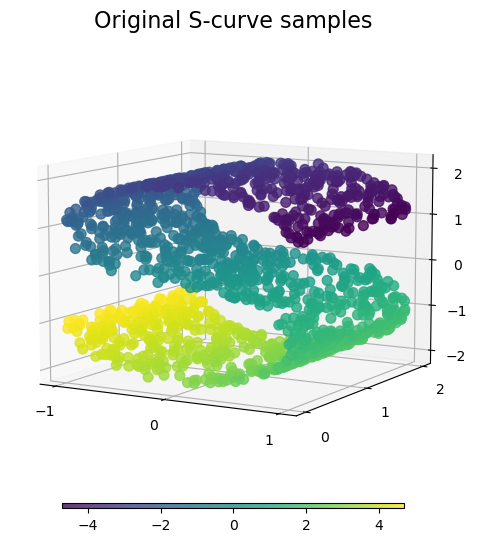

In [ ]:
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
from matplotlib import ticker

from sklearn import datasets, manifold

n_samples = 1500
S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)

def plot_3d(points, points_color, title):
    x, y, z = points.T

    fig, ax = plt.subplots(
        figsize=(6, 6),
        facecolor="white",
        tight_layout=True,
        subplot_kw={"projection": "3d"},
    )
    fig.suptitle(title, size=16)
    col = ax.scatter(x, y, z, c=points_color, s=50, alpha=0.8)
    ax.view_init(azim=-60, elev=9)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.zaxis.set_major_locator(ticker.MultipleLocator(1))

    fig.colorbar(col, ax=ax, orientation="horizontal", shrink=0.6, aspect=60, pad=0.01)
    plt.show()

plot_3d(S_points, S_color, title="Original S-curve samples")

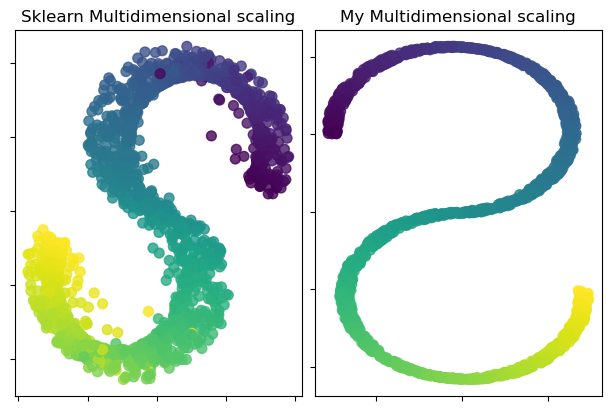

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2,
    figsize=(6, 4),
    facecolor="white",
    constrained_layout=True,
)

def plot_2d(points, points_color, fig_ax, title):
    _, ax = fig_ax
    add_2d_scatter(ax, points, points_color, title=title)

def add_2d_scatter(ax, points, points_color, title=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

md_scaling = manifold.MDS(
    n_components=2,
    max_iter=50,
    n_init=1,
    random_state=0,
    normalized_stress=False,
)
S_scaling = md_scaling.fit_transform(S_points)

plot_2d(S_scaling, S_color, fig_ax=(fig, ax[0]), title="Sklearn Multidimensional scaling")

mds=cMDS(nb_comp=2)
S_scaling=mds.fit_transform(S_points)
plot_2d(S_scaling, S_color, fig_ax=(fig, ax[1]), title="My Multidimensional scaling")
plt.show()

## Isomap

It stands for *Isometric Feature Mapping*. The core novelty in the approach is that it does not rely anymore on the euclidian distance, based on an euclidian space, but on the geodesic distance. This distance precisely rely on the manifold from which the data belongs, but it is in the vast majority of time unknown. Instead, apply the three next steps:

> 1.  Build a large graph to connect points together via edges weighted by their euclidian distance. There's two approaches:
    >> 1. $\epsilon$-ball approach. Neighbours of point $i$ are all points within a ball of radius $\epsilon$.
    >> 2. kNN approach. Neighbours are the $k-$ nearest neighbours.
> 2. Compute the shortest path (i.e. the manifold distance) between all pair of vertices with Dijkstra's algorithm.
> 3. Apply Multi-Dimensional Scaling (MDS) to find a $k-$ dimensional representation of the dataset.

Note the fundamental difference between the $\epsilon-$ ball and kNN approach. In the latter, the manifold distance between node $i$ and $j$ is not symmetric. Indeed, even if $j$ is a nearest neighbour to $i$, the converse is not necessarily true, making the path from $i$ to $j$ different than going from $j$ to $i$. It does not hold for the $\epsilon-$ ball strategy because $x_j \in B(x_i, \epsilon) \iff x_i \in B(x_j, \epsilon)$.

In [64]:
import numpy as np
from sklearn.base import TransformerMixin, BaseEstimator
import heapq

def Linear(gamma: float=None, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        #Vectorize scalar product
        if len(x.shape) == len(y.shape) and len(x.shape) > 1:
            if on_diagonal:
                return np.einsum('ij, ij -> i', x, y)
            return np.einsum('ij, kj -> ik', x, y)
        return x @ y.T
    return kernel

def RBF(gamma: float = 1, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        if on_diagonal:
            expo=-(np.sum((x - y)**2, axis = -1))/(2*gamma) #Sum along the data dimension
        else:
            expo = -(np.sum((x[:,None,:] - y[None,:,:])**2, axis = -1))/(2*gamma) #Sum along the data dimension
        return np.exp(expo)
    return kernel

def poly(gamma: int, c:float=1):
    assert type(gamma)==int, "Power parameter should be an integer."
    lin=Linear()
    def kernel(x, y, on_diagonal: bool=False):
        return np.pow((c + lin(x, y, on_diagonal)), gamma)
    return kernel

def sigmoid(gamma: float=1, c: float=1):
    lin=Linear()
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        return np.tanh(gamma*lin(x, y, on_diagonal) + c)
    return kernel

dict_kernel=dict({"linear": Linear, "gaussian": RBF, "polynomial": poly})

class Isomap(TransformerMixin, BaseEstimator):
    def __init__(self, nb_comp: int=2, type: str="kNN", kernel: str='linear', k: int=4, epsilon: float=None, gamma: float=1, c: float=1):
        list_type=('eps_ball', 'kNN')
        self.k=k
        self.nb_comp=nb_comp
        self.epsilon=epsilon
        assert type in list_type, "type should be either 'kNN' or 'eps_ball'."
        self.type=type
        self.kernel=dict_kernel.get('linear')(gamma, c)
        self.X=None

        self.is_fitted=False
        self.X_embedd=None

    def compute_dist(self, x, y, on_diagonal: bool=False):
        """
        Compute the squared distance between x and y.
        """
        return self.kernel(x, x, on_diagonal=on_diagonal)[None,...] + self.kernel(y, y, on_diagonal=on_diagonal)[:,None,...] - 2*self.kernel(x, y)

    def find_knearest_neighbours(self, x, X, test: bool=False):
        """
        x should be included in X if test is False.
        """
        D=self.kernel(x,x) + self.kernel(X, X, on_diagonal=True) - 2*self.kernel(x,X)
        Index=[]
        if not test:
            D[np.argmin(D)]=np.infty
        for _ in range(self.k):
            idx=np.argmin(D)
            Index.append((idx, D[idx]))
            D[idx]=np.infty
        return np.array(Index)

    def build_graph(self):
        N=len(self.X)
        graph=[]
        if self.type=="kNN":
            for x in self.X:
                Index=self.find_knearest_neighbours(x, self.X)
                graph.append(Index)
        elif self.type=='eps_ball':
            for i in range(N):
                self.D[i, i]=np.infty
                Index=np.where(np.sqrt(self.D[i]) < self.epsilon)[0]
                Index=np.concatenate((Index[...,None], self.D[i, Index][...,None]), axis=-1)
                graph.append(Index)
        return graph

    def Dijkstra_algorithm(self, start_node, graph):
        """
        Apply Dijsktra's algorithm on the graph. Find all the shortest path from start_node
        to all other nodes. This time, one uses a min-heap data structure to recover easily 
        Requires: positively weighted graph. Time complexity scales as O(|V| + |E| log(|V|)).
        """

        nb_node = len(self.X)
        value=[[np.inf, i] for i in range(nb_node)]
        unvisited = set(range(nb_node))
        value[start_node] = [0, start_node]

        graph_distance=[]

        heapq.heapify(value)
        while not len(unvisited)==0:
            v=heapq.heappop(value) #Closest node to start_node
            val=v[0]
            idx=v[1]
            graph_distance.append([idx, val])
            unvisited.remove(idx)
            neigh = graph[idx]
            value_array=np.array(value)
            for n, weight in neigh:
                if n in unvisited:
                    n=n.astype(int)
                    m=np.where(value_array[:,1]==n)[0]
                    if value[m.item()][0]>val+weight:
                        value[m.item()][0]=val+weight
            heapq.heapify(value)
        graph_distance.sort(key=lambda x: x[0])
        return graph_distance

    def manifold_distance(self):
        N=len(self.X)
        self.D=self.compute_dist(self.X, self.X, on_diagonal=True)
        graph=self.build_graph()
        Value=[]
        for i in range(N):
            val=self.Dijkstra_algorithm(i, graph)
            Value.append(val)
        return np.array(Value)

    def fit(self, X: np.ndarray):
        self.X=X
        Value=self.manifold_distance()
        mds=cMDS(self.nb_comp)
        self.X_embedd=mds.fit_transform(Value[...,1])
        self.is_fitted=True

    def fit_transform(self, X: np.ndarray):
        if not self.is_fitted:
            self.is_fitted=True
            self.fit(X)
        assert self.X_embedded is not None, "The embedding should have been calculated."
        return self.X_embedded

X=np.random.randn(4, 2)
Is=Isomap(type="eps_ball", epsilon=3, k=2)
Is.fit(X)


In [ ]:
from sklearn import datasets, manifold
import matplotlib.pyplot as plt


n_samples = 1500
S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)


fig, ax = plt.subplots(nrows=1, ncols=2,
    figsize=(6, 4),
    facecolor="white",
    constrained_layout=True,
)

def plot_2d(points, points_color, fig_ax, title):
    _, ax = fig_ax
    add_2d_scatter(ax, points, points_color, title=title)

def add_2d_scatter(ax, points, points_color, title=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

isomap = manifold.Isomap(n_neighbors=12, n_components=2, p=1)
S_isomap = isomap.fit_transform(S_points)

plot_2d(S_isomap, S_color, fig_ax=(fig, ax[0]), title="Sklearn Isomap Embedding")

Iso=Isomap(nb_comp=2, k=12)
S_isomap=Iso.fit_transform(S_points)
plot_2d(S_scaling, S_color, fig_ax=(fig, ax[1]), title="My Isomap Embedding")
plt.show()

## Locally linear embedding

It is a three steps algorithm [1].

> 1. ($k-$ Nearest neighbours) For each data point, finds its $k$ nearest neighbours, based on the Euclidian distance. You can build a kNN graph. This steps can be very time consuming, since you need to make a a greedy-search for each point. It scales as $\mathcal{O}(N^2)$.
> 2. (Linear Reconstruction by the Neighbours) Then, you find optimal weights to reconstruct a data point as a linear combination of its $k$ nearest neighbours.
> 3. (Linear embedding) Eventually, you solve an optimization problem to translate data points in reduced point by preserving the local structure between a point and its neighborhood. This optimization problem turns out to be strictly to an eigenvalue problem.

Assuming that first step has been processed, i.e., that to each data point $x_i$ is associated $X_i=(x_{i1}, x_{i2}, \cdots, x_{ik}) \in \mathbb{R}^{n \times k}$ concatenating its $k$ nearest neighbours. Now, the idea would be that find weights $W_i$ that approximates at best $x_i$ as a linear combination of $X_i$: $x_i \approx X_i W_i$.

The optimization problem can be formulated:
$$
\begin{array}{cc}
\min\limits_{W_i \in \mathbb{R}^{k}} & \sum\limits_{i=1}^N ||x_i - X_iW_i||_2^2 \\
\text{s.t} & \mathbb{1}^\top W_i = 1 \, \forall i \in \{1, \cdots, N\}
\end{array}
$$

An analytical solution can be easily found. It is expressed as:
$$
W_i=\frac{G_i^{-1}\mathbb{1}}{\mathbb{1}^\top G_i^{-1}\mathbb{1}},
$$
where $G_i=(x_i \mathbb{1}^\top - X_i)^\top(x_i \mathbb{1}^\top - X_i)$.

Once the weights have been calculated, you want to embed data in the low dimensional space by constructing points $(y_1, \cdots, y_N)$ as linear combinations of its neighbours, whose positions remains also to be determined. The optimization problem takes the form:

$$
\begin{array}{cc}
\min\limits_{y \in \mathbb{R}^{N \times m}} & \sum\limits_{i=1}^N ||y_i - \sum\limits_{j=1}^n y_j\tilde{w}_{ij}||_2^2 \\
\text{s.t} & \sum\limits_{i=1}^N y_i = 0 \, \text{(centered)}\\
& \frac1N \sum\limits_{i=1}^N y_i y_i^\top=I \, \text{(unit variance)}
\end{array}
$$

Note that the optimization variables are now $(y_i)_{i \in \{1, \cdots, N\}}$, and not the weights anymore. Also, there is a direct bijection between data points $(x_i)_{i \in \{1, \cdots, N\}}\mathbb{R}^{N\times n}$ and $(y_i)_{i \in \{1, \cdots, N\}}\mathbb{R}^{N\times m}$, meaning that $y_i$ is the representant of $x_i$ in the low dimensional space. Also, if $x_j$ is a nearest neighbours of $x_i$, then so is $y_j$ for $y_i$. That's why $\tilde{w}_{ij}=w_{ij}$ if $x_j$ is a nearest neighbours of $x_i$, and $0$ otherwise. By setting $M=(I-\tilde{W})^\top(I-\tilde{W}) \in \mathbb{R}^{N\times N}$, it admits the following matrix formulation:
$$
\begin{array}{cc}
\min\limits_{Y \in \mathbb{R}^{N \times m}} & \text{Tr}(Y^\top M Y) \\
\text{s.t} & Y^\top \mathbb{1}=0 \\
& \frac1N Y^\top Y=I
\end{array}
$$

This problem can be formulated as an eigenvalue problem. Indeed, ignoring the centering constraint, and nulling the gradient of the Lagrangian:
$ \mathcal{L}(Y, \Lambda)= \text{Tr}(Y^\top MY) + \text{Tr}(\Lambda^\top (\frac1N Y^\top Y-I))$ yields the equation:
$$
MY=Y\frac1N \Lambda.
$$

You should then take $y_i \in \mathbb{R}^{m}$ as the $i-$ th coordinate of the $m$ *smallest* eigenvectors because it is a minimization problem.

### Kernel LLE
The first step is quite similar, except that it is the distance is computed in the feature space, that is: $d(x_i, x_j) = ||\phi(x_i) - \phi(x_j)||^2=k(x_i,x_i) + k(x_j, x_j) - 2k(x_i, x_j)$. The $k-$ nearest neighbours should be computed according to this distance.

Also, the second step is very similar, only the Gram matrix changes. The optimization problem admits the form:
$$
\begin{array}{cc}
\min\limits_{W_i \in \mathbb{R}^k} & \sum\limits_{i=1}^N ||\phi(x_i) - \phi(X_i)W_i||_2^2 \\
\text{s.t} & \mathbb{1}^\top W_i = 1 \, \forall i \in \{1, \cdots, N\}
\end{array}
$$

The solution admits the following closed expression:
$$
W_i=\frac{K_i^{-1}\mathbb{1}}{\mathbb{1}^\top K_i^{-1}\mathbb{1}},
$$
where $K_i \in \mathbb{R}^{k \times k}=(\langle \phi(x_i) - \phi(x_{ia}), \phi(x_i) - \phi(x_{ib})\rangle_{\mathcal{H}})_{(a,b) \in \{1, \cdots, N\}^2}$. $x_{ia}$ and $x_{ib}$ are respectively the $a$-th and $b$-th nearest neighbours of $x_i$.

The linear embedding step is exactly the same.

### Out-of-Samples embedding
Now that the model was fit on training dataset, how could we embed a test data point, which have not beed used in the training, into the low dimensional space. Quite intuitively, you could first find the $k-$ nearest neighbours among the training data set, and then compute the weights to find the best approximation of the test data point as a linear combinations of its nearest neighbours. Test data point will be noted with the $(t)$ superscript. Let $x_i^{(t)}$ the $i-$ th test data point and $X_i^{(t)}=(x_{i1}^{(t)}, \cdots, x_{ik}^{(t)})$ the $k-$ nearest neighbours. Following the exact same reasonning as before, the optimal weights are given by:
$$
W_i^{(t)}=\frac{G_i^{(t)-1}\mathbb{1}}{\mathbb{1}^\top G_i^{(t)-1}\mathbb{1}},
$$
with $G_i^{(t)}=(x_i^{(t)}\mathbb{1}^\top - X_i^{(t)})^\top (x_i^{(t)}\mathbb{1}^\top - X_i^{(t)})$ and $\mathbb{1}=(1, \cdots, 1) \in \mathbb{R}^k$.
Next, the embedding of $x_i^{(t)}$ is simply: $y_i^{(t)}=\sum\limits_{j=1}^k w_{i,j}y_{ij}^{(t)}$. Again, keep in mind that all $y_{ij}^{(t)}$ are the embedding of training data points, determined during training phase.

Note the existence of supervised LLE and landmark LLE. The first one takes into account the case where data come with labels. The distance matrix is slightly modified. Landmark LLE introduces approximations to make the computation practicable when $N \gg 1$. See Nyström approximation.

[1] [Locally Linear Embedding and its variants](https://arxiv.org/pdf/2011.10925)

In [3]:
import numpy as np
def Linear(gamma: float=None, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        #Vectorize scalar product
        if len(x.shape) == len(y.shape) and len(x.shape) > 1:
            if on_diagonal:
                return np.einsum('ij, ij -> i', x, y)
            return np.einsum('ij, kj -> ik', x, y)
        return x @ y.T
    return kernel

def RBF(gamma: float = 1, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        if on_diagonal:
            expo=-(np.sum((x - y)**2, axis = -1))/(2*gamma) #Sum along the data dimension
        else:
            expo = -(np.sum((x[:,None,:] - y[None,:,:])**2, axis = -1))/(2*gamma) #Sum along the data dimension
        return np.exp(expo)
    return kernel

def poly(gamma: int, c:float=1):
    assert type(gamma)==int, "Power parameter should be an integer."
    lin=Linear()
    def kernel(x, y, on_diagonal: bool=False):
        return np.pow((c + lin(x, y, on_diagonal)), gamma)
    return kernel

def sigmoid(gamma: float=1, c: float=1):
    lin=Linear()
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        return np.tanh(gamma*lin(x, y, on_diagonal) + c)
    return kernel

In [ ]:
dict_kernel=dict({"linear": Linear, "gaussian": RBF, "polynomial": poly})

class LLE(object):
    def __init__(self, k: int, nb_comp: int, kernel: str='linear', *args, **kwargs):
        self.k=k #Number of nearest neighbours
        self.nb_comp=nb_comp
        self.kernel=dict_kernel.get(kernel, None)(**kwargs)

        self.X_embedded=None
        self.is_fitted=False

    def compute_dist(self, x, y, on_diagonal: bool=False):
        """
        Compute the squared distance between two points.
        """
        return self.kernel(x, x) + self.kernel(y, y, on_diagonal=on_diagonal) - 2*self.kernel(x, y)

    def find_knearest_neighbours(self, x, X, test:bool=False):
        """
        x should be included in X if test is False.
        """

        D=self.compute_dist(x, X, on_diagonal=True).astype(float)
        Index=[]
        if not test:
            D[np.argmin(D)]=np.infty
        for _ in range(self.k):
            idx=np.argmin(D)
            Index.append(idx)
            D[idx]=np.infty
        return np.array(Index).astype(int)

    def fit(self, X):
        N=len(X)
        d=X.shape[-1]
        self.X=X
        NN=np.empty((N, self.k, d))
        Index=np.empty((N, self.k), dtype=np.int16)

        for i, x in enumerate(X):
            Index[i]=self.find_knearest_neighbours(x, X)
            NN[i]=X[Index[i]]
        K=np.empty((N, self.k, self.k))
        for i in range(N):
            K[i]=self.kernel(X[i], X[i]) - 2*self.kernel(X[i], NN[i]) + self.kernel(NN[i], NN[i])

        inv_K=np.linalg.solve(K, np.ones((N, self.k)))
        self.weights=inv_K/(inv_K @ np.ones((self.k,1)))

        W=np.zeros((N,N))
        for i in range(N):
            W[i, Index[i]]=self.weights[i]

        M=(np.eye(N) - W.T) @ (np.eye(N) - W)

        _, eigvec=np.linalg.eigh(M)
        self.X_embedded=eigvec[:,:self.nb_comp]
        self.is_fitted=True

    def transform(self, X_test):
        N_test=len(X_test)
        N=len(self.X)
        d=X.shape[-1]
        assert self.is_fitted, "You should fit the model first."
        NN=np.empty((N_test, self.k, d))
        Index=np.empty((N_test, self.k))

        for i, x in enumerate(X_test):
            Index[i]=self.find_knearest_neighbours(x, self.X, test=True)
            NN[i]=X[Index]

        K=np.empty((N_test, self.k, self.k))

        for i in range(N):
            K[i]=self.kernel(X_test[i], X_test[i]) - 2*self.kernel(X_test[i], NN[i]) + self.kernel(NN[i], NN[i])

        inv_K=np.linalg.solve(K, np.ones(self.k)[None,...])
        weights=inv_K/(inv_K @ np.ones((self.k,1))) #Should be of size N_test x self.k

        return np.sum(self.X_embedded[Index]*weights[...,np.newaxis], axis=1)

    def fit_transform(self, X):
        if not self.is_fitted:
            self.is_fitted=True
            self.fit(X)
        assert self.X_embedded is not None, "The embedding should have been calculated."
        return self.X_embedded


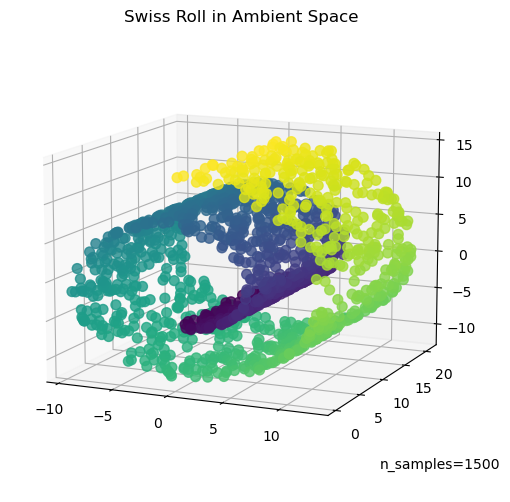

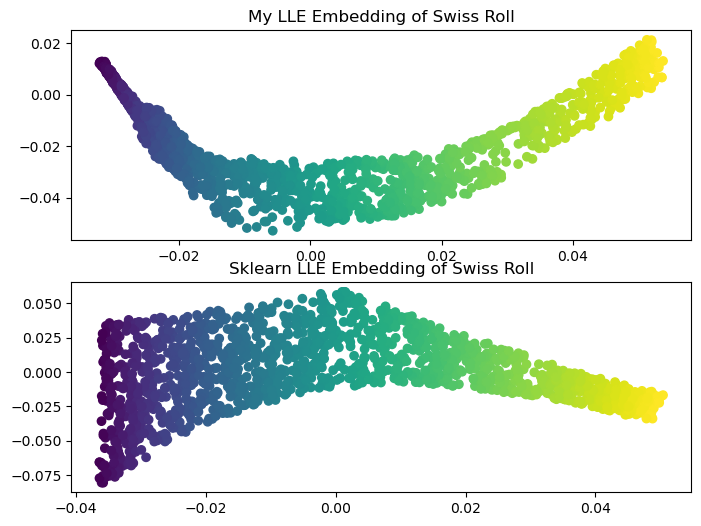

In [7]:
import matplotlib.pyplot as plt

from sklearn import datasets, manifold

sr_points, sr_color = datasets.make_swiss_roll(n_samples=1500, random_state=0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
fig.add_axes(ax)
ax.scatter(
    sr_points[:, 0], sr_points[:, 1], sr_points[:, 2], c=sr_color, s=50, alpha=0.8
)
ax.set_title("Swiss Roll in Ambient Space")
ax.view_init(azim=-66, elev=12)
_ = ax.text2D(0.8, 0.05, s="n_samples=1500", transform=ax.transAxes)

ll=LLE(k=12, nb_comp=2)
sr_lle=ll.fit_transform(sr_points)

skl_sr_lle, _=manifold.locally_linear_embedding(sr_points, n_components=2, n_neighbors=12)

fig, axs = plt.subplots(figsize=(8, 6), nrows=2)
axs[0].scatter(sr_lle[:, 0], sr_lle[:, 1], c=sr_color)
axs[0].set_title("My LLE Embedding of Swiss Roll")

axs[1].scatter(skl_sr_lle[:, 0], skl_sr_lle[:, 1], c=sr_color)
axs[1].set_title("Sklearn LLE Embedding of Swiss Roll")

plt.show()

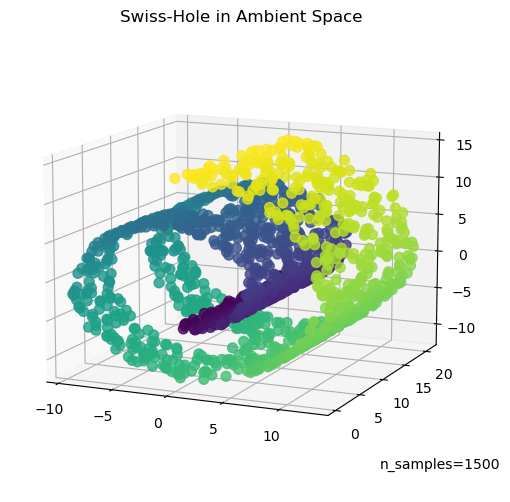

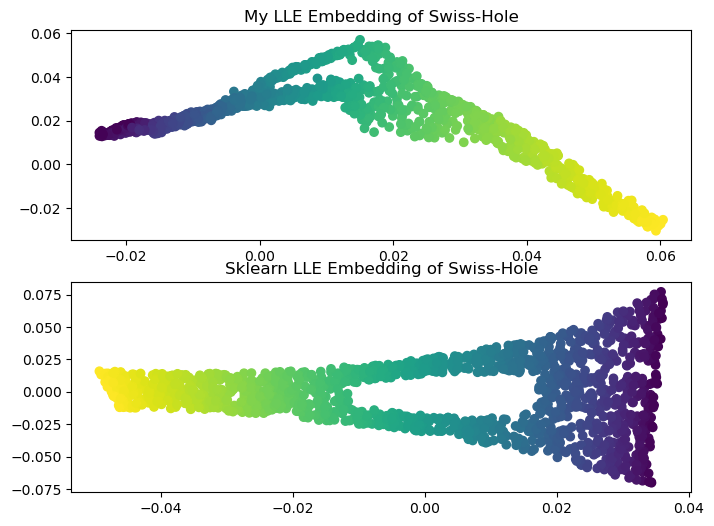

In [65]:
sh_points, sh_color = datasets.make_swiss_roll(
    n_samples=1500, hole=True, random_state=0
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
fig.add_axes(ax)
ax.scatter(
    sh_points[:, 0], sh_points[:, 1], sh_points[:, 2], c=sh_color, s=50, alpha=0.8
)
ax.set_title("Swiss-Hole in Ambient Space")
ax.view_init(azim=-66, elev=12)
_ = ax.text2D(0.8, 0.05, s="n_samples=1500", transform=ax.transAxes)

ll=LLE(k=12, nb_comp=2)
sh_lle=ll.fit_transform(sh_points)

skl_sh_lle, _=manifold.locally_linear_embedding(sh_points, n_components=2, n_neighbors=12)

fig, axs = plt.subplots(figsize=(8, 6), nrows=2)
axs[0].scatter(sh_lle[:, 0], sh_lle[:, 1], c=sh_color)
axs[0].set_title("My LLE Embedding of Swiss-Hole")

axs[1].scatter(skl_sh_lle[:, 0], skl_sh_lle[:, 1], c=sh_color)
axs[1].set_title("Sklearn LLE Embedding of Swiss-Hole")

plt.show()

[Out-of-Sample Extensions for LLE, Isomap,
 MDS, Eigenmaps, and Spectral Clustering](https://proceedings.neurips.cc/paper_files/paper/2003/file/cf05968255451bdefe3c5bc64d550517-Paper.pdf)